# Segmentación de tipos de frijoles secos con k-means clustering

**Dataset:** [Dry Bean Dataset — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/602/dry+bean+dataset)


## 1. Introducción y descripción del problema

El objetivo de este proyecto es segmentar diferentes tipos de frijoles secos en grupos homogéneos según sus características morfológicas (forma, tamaño, textura), utilizando el algoritmo de clustering **K-Means**.

### ¿Por qué es importante?

La clasificación y segmentación de semillas agrícolas permite a productores e investigadores identificar variedades de forma automatizada, optimizar procesos de selección y control de calidad, y reducir la dependencia de clasificación manual, que es costosa y propensa a errores.

### 1.2 Descripción del dataset

- **Nombre:** Dry_Bean_Dataset.csv  
- **Fuente:** UCI Machine Learning Repository  
- **Observaciones:** 13,611 muestras de frijoles secos  
- **Variables morfológicas principales:**
  - `Area`: Área de la zona del frijol
  - `Perimeter`: Longitud del perímetro del frijol
  - `MajorAxisLength`: Longitud del eje mayor de la elipse equivalente
  - `MinorAxisLength`: Longitud del eje menor de la elipse equivalente
  - `Compactness`: Relación entre el área y el perímetro al cuadrado
  - `Class`: Tipo de frijol (Seker, Barbunya, Bombay, Cali, Horoz, Sira, Dermason)

Para este análisis se utilizan las variables: **Area, Perimeter, MajorAxisLength, MinorAxisLength y Compactness**.

## 2. Carga y exploración de datos

En esta etapa se importan las librerías necesarias para el análisis y modelado de datos. Cada librería cumple un rol específico:

- **`pandas`**: manejo y análisis de datos en forma de tablas (DataFrames)
- **`numpy`**: operaciones matemáticas y manejo de arreglos numéricos
- **`matplotlib.pyplot`**: creación de gráficas y visualizaciones
- **`seaborn`**: visualizaciones estadísticas de alto nivel sobre matplotlib
- **`StandardScaler`**: estandarización de variables para que tengan la misma escala
- **`KMeans`**: algoritmo de clustering para agrupar los datos
- **`silhouette_score`**: métrica para evaluar la calidad del agrupamiento
- **`PCA`**: reducción de dimensionalidad para visualizar clusters en 2D
- **`joblib`**: serialización y guardado del modelo entrenado

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import joblib
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

### 2.1 Carga del dataset

Se carga el dataset desde un archivo CSV hacia un DataFrame de pandas, lo que permite manipular y analizar los datos en las etapas siguientes.

In [4]:
from src.preprocessing import load_data, get_features 
df = load_data('../data/processed/Dry_Bean_Dataset_clean.csv')

### 2.2 Información general del dataset

Se muestran las primeras filas del dataset con `head()` para tener una vista rápida de su estructura: columnas, tipos de datos y valores de ejemplo.

In [5]:
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


`info()` muestra el número total de filas y columnas, el tipo de dato de cada columna y la cantidad de valores no nulos, lo que permite detectar columnas con datos faltantes.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

`describe()` calcula un resumen estadístico de las columnas numéricas: promedio, desviación estándar, mínimo, máximo y percentiles. Esto permite entender la distribución general de cada variable antes de modelar.

In [7]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


## 3. Análisis Eexploratorio de datos (EDA)

Se analizan las distribuciones, correlaciones, valores nulos y posibles outliers en los datos, con el fin de comprender la estructura del dataset y preparar correctamente el modelo.

### 3.1 Valores nulos

`isnull().sum()` detecta y cuenta los valores vacíos (`NaN`) en cada columna. Es fundamental verificar esto antes del modelado, ya que los algoritmos de machine learning no pueden operar con datos faltantes.

In [8]:
df.isnull().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

### 3.2 Distribuciones de variables

Los histogramas muestran cómo se distribuyen todas las variables numéricas del dataset. Permiten identificar si los datos siguen distribuciones normales, si están sesgados hacia algún extremo, o si existen concentraciones particulares de valores que puedan influir en el clustering.

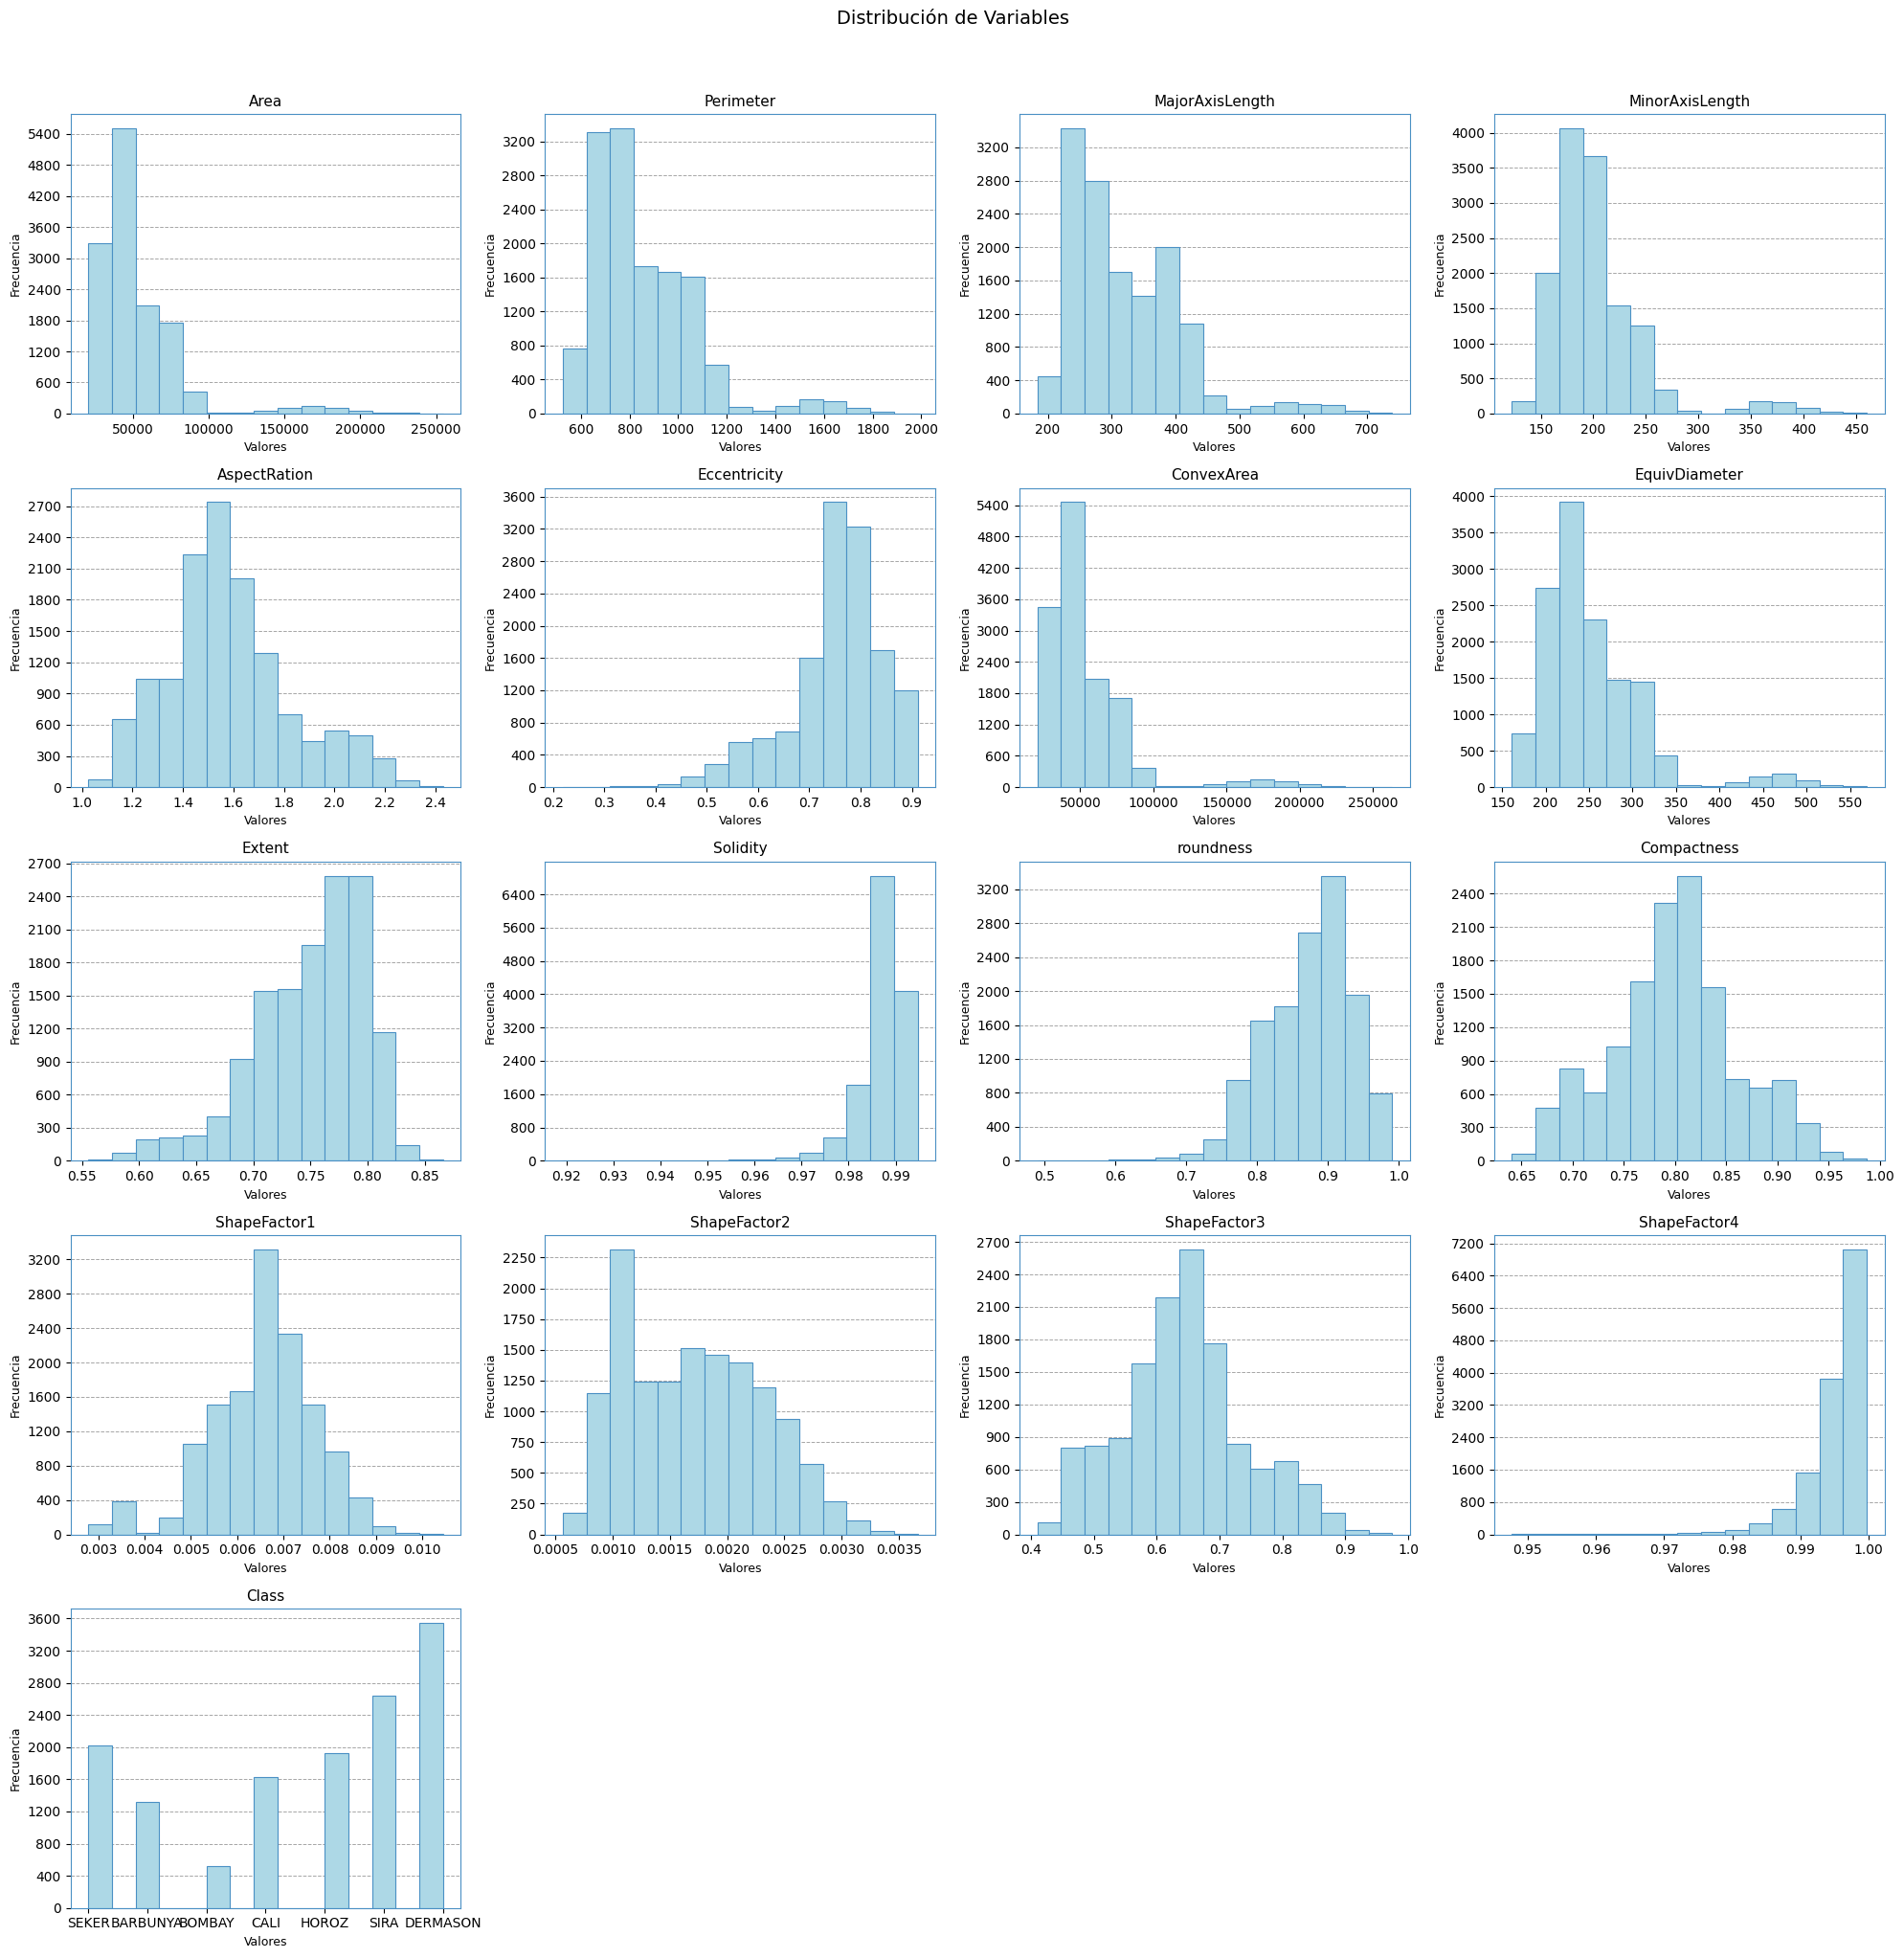

In [ ]:
cols_list = df.columns.tolist()
n_cols = 4  # columnas por fila
n_rows = int(np.ceil(len(cols_list) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_list):
    ax = axes[i]
    ax.hist(
        df[col].dropna(),
        bins=15,
        color='#add8e6',
        edgecolor='#4a90c4',
        linewidth=0.8
    )
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Valores', fontsize=9)
    ax.set_ylabel('Frecuencia', fontsize=9)
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7, color='gray')
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_edgecolor('#4a90c4')
        spine.set_linewidth(0.8)

# Ocultar subgráficas vacías si el total no es múltiplo de n_cols
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Correlaciones

La matriz de correlación muestra qué tan relacionadas están las variables entre sí. Un valor cercano a 1 indica correlación positiva fuerte, cercano a -1 correlación negativa fuerte, y cercano a 0 indica poca relación. En este caso, se espera que variables morfológicas como `Area` y `Perimeter` estén altamente correlacionadas, ya que frijoles más grandes tienden a tener perímetros más extensos.

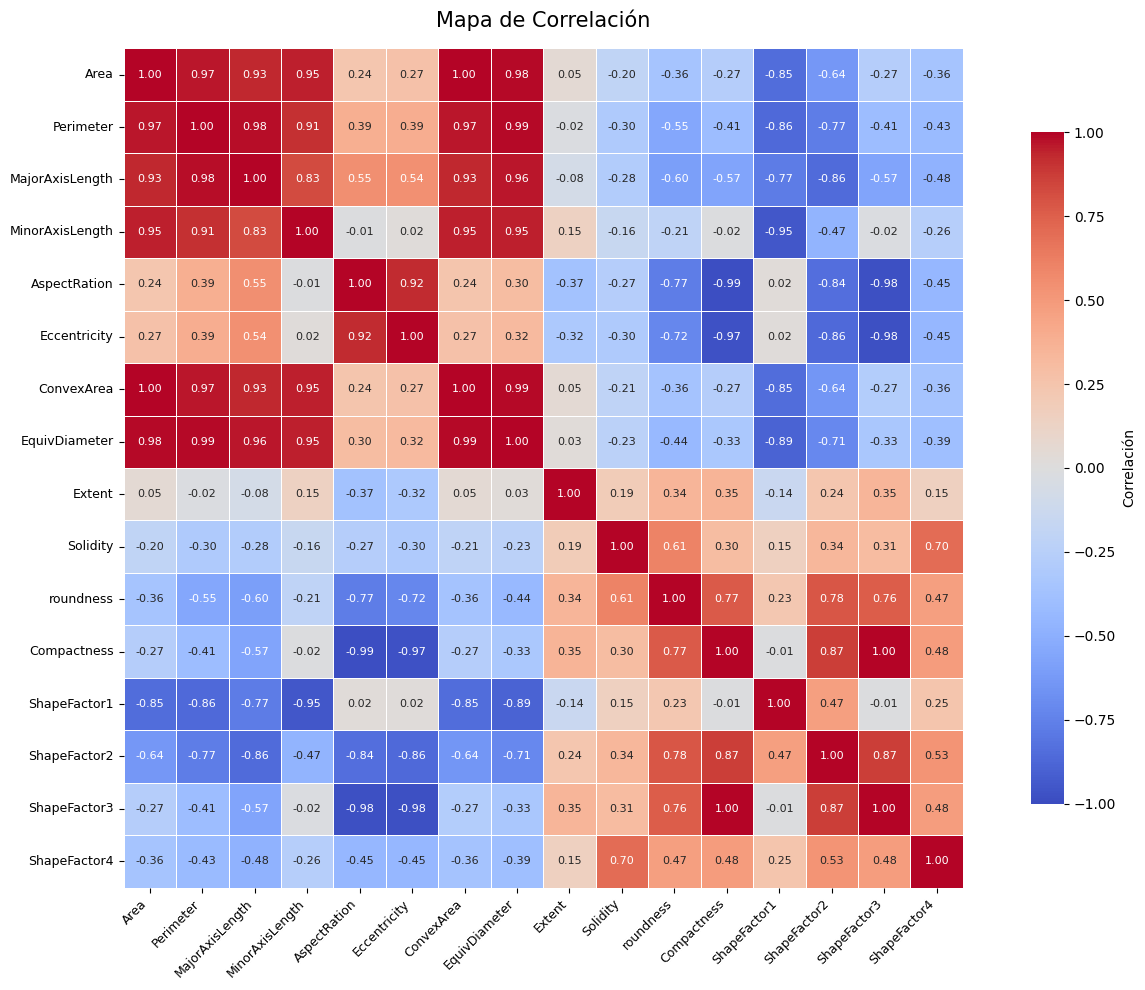

In [ ]:
plt.figure(figsize=(14, 10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8},
    linewidths=0.5,
    linecolor='white',
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Correlación'}
)

plt.title('Mapa de correlación', fontsize=15, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

### 3.4 Outliers

Los diagramas de caja (boxplots) permiten visualizar la dispersión de cada variable y detectar valores atípicos (outliers), representados como puntos fuera de los bigotes. Esta información es relevante para el clustering, ya que los outliers pueden distorsionar los centroides del modelo K-Means. Se analizan las cinco variables morfológicas seleccionadas.

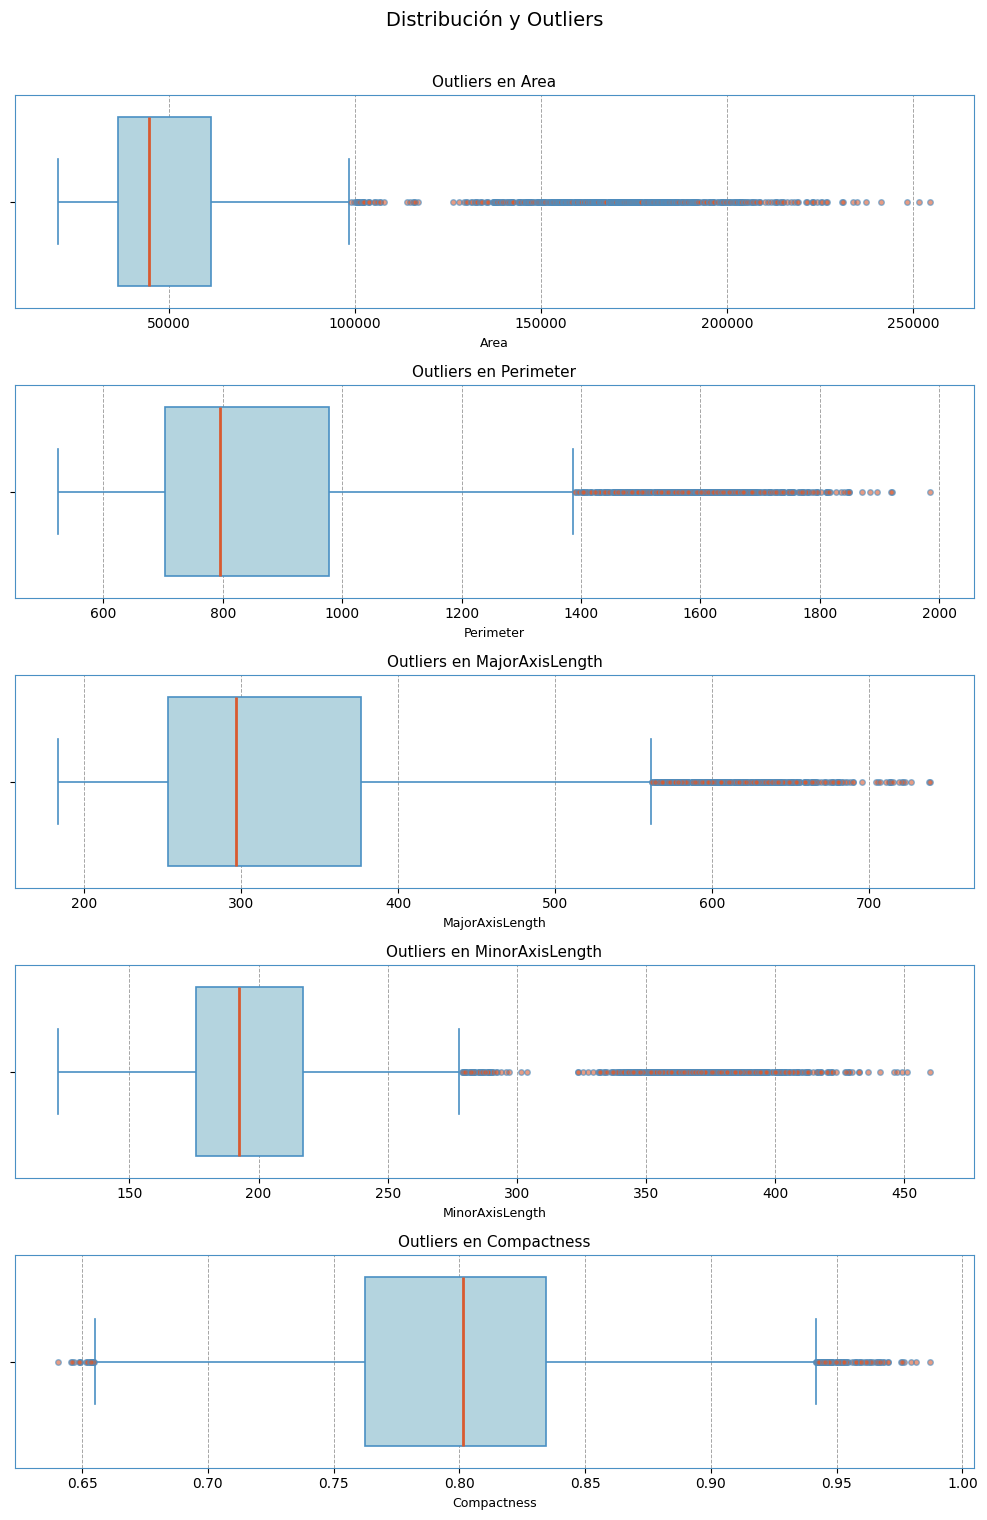

In [ ]:
features_boxplot = [
    'Area',
    'Perimeter',
    'MajorAxisLength',
    'MinorAxisLength',
    'Compactness'
]

fig, axes = plt.subplots(len(features_boxplot), 1, figsize=(10, len(features_boxplot) * 3))

for ax, col in zip(axes, features_boxplot):
    sns.boxplot(
        x=df[col],
        ax=ax,
        color='#add8e6',
        linecolor='#4a90c4',
        linewidth=1.2,
        flierprops=dict(marker='o', markerfacecolor='#d85a30', markersize=4, alpha=0.6),
        boxprops=dict(edgecolor='#4a90c4'),
        whiskerprops=dict(color='#4a90c4'),
        capprops=dict(color='#4a90c4'),
        medianprops=dict(color='#d85a30', linewidth=2)
    )
    ax.set_title(f'Outliers en {col}', fontsize=11)
    ax.set_xlabel(col, fontsize=9)
    ax.grid(axis='x', linestyle='--', linewidth=0.7, alpha=0.7, color='gray')
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_edgecolor('#4a90c4')
        spine.set_linewidth(0.8)

plt.suptitle('Distribución y outliers', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Preprocesamiento

En esta etapa se preparan los datos para el modelado: se seleccionan las variables relevantes, se separa la matriz de características y se estandarizan los datos.

### 4.1 Selección de variables para clustering

Se seleccionan las cinco variables morfológicas más representativas del frijol. Estas características capturan la forma y tamaño de cada muestra, que son las dimensiones más útiles para diferenciar tipos de frijoles. Se descarta la columna `Class` ya que el clustering es un proceso no supervisado.

In [20]:
features = [
    'Area',
    'Perimeter',
    'MajorAxisLength',
    'MinorAxisLength',
    'Compactness'
]

In [21]:
X = df[features]

In [22]:
X.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,Compactness
0,28395,610.291,208.178117,173.888747,0.913358
1,28734,638.018,200.524796,182.734419,0.953861
2,29380,624.110,212.826130,175.931143,0.908774
3,30008,645.884,210.557999,182.516516,0.928329
4,30140,620.134,201.847882,190.279279,0.970516


### 4.2 Escalado de datos

Se aplica **estandarización** con `StandardScaler` para que todas las variables tengan media 0 y desviación estándar 1. Este paso es fundamental en K-Means porque el algoritmo calcula distancias entre puntos: si las variables tienen escalas muy diferentes (por ejemplo, `Area` en miles vs `Compactness` entre 0 y 1), las variables con valores más grandes dominarán el cálculo de distancias y sesgarán los clusters.

In [23]:
from src.preprocessing import scale_features 
X_scaled, scaler = scale_features(X)

## 5. Ajuste de hiperparámetros

Se evalúan distintos valores de `k` o el número de clusters en el modelo K-Means utilizando el **Silhouette Score** como métrica de calidad. Esta métrica mide qué tan cohesionados están los puntos dentro de su propio cluster en comparación con los clusters vecinos:

- Valores cercanos a **1**: excelente separación entre clusters
- Valores cercanos a **0**: clusters con solapamiento
- Valores **negativos**: mala asignación de puntos

El parámetro `n_init=10` indica que el algoritmo se ejecuta 10 veces con inicializaciones aleatorias diferentes, y se conserva el mejor resultado, lo que reduce la sensibilidad a condiciones iniciales.

In [24]:
silhouette_scores = []

K = range(2,11)

best_score = -1
best_k = 2

for k in K:
    
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X_scaled)
    
    labels = model.labels_
    
    score = silhouette_score(X_scaled, labels)
    
    silhouette_scores.append(score)
    
    print(f'Clusters: {k} | Score: {score}')
    
    if score > best_score:
        
        best_score = score
        best_k = k

print('\n======================')
print(f'Mejor número de clusters: {best_k}')
print(f'Mejor Silhouette Score: {best_score}')

Clusters: 2 | Score: 0.498165421071276
Clusters: 3 | Score: 0.5190007679364604
Clusters: 4 | Score: 0.4852871302925539
Clusters: 5 | Score: 0.45391547873545807
Clusters: 6 | Score: 0.47197334943993985
Clusters: 7 | Score: 0.4509786100377219
Clusters: 8 | Score: 0.40485118305715245
Clusters: 9 | Score: 0.39480128078032134
Clusters: 10 | Score: 0.3851005794061803

Mejor número de clusters: 3
Mejor Silhouette Score: 0.5190007679364604


### 5.1 Selección del número óptimo de clusters (k)

La gráfica de Silhouette Score vs. número de clusters permite visualizar cuál valor de `k` produce el mejor agrupamiento. El pico más alto en la curva indica el número óptimo de clusters para este dataset.

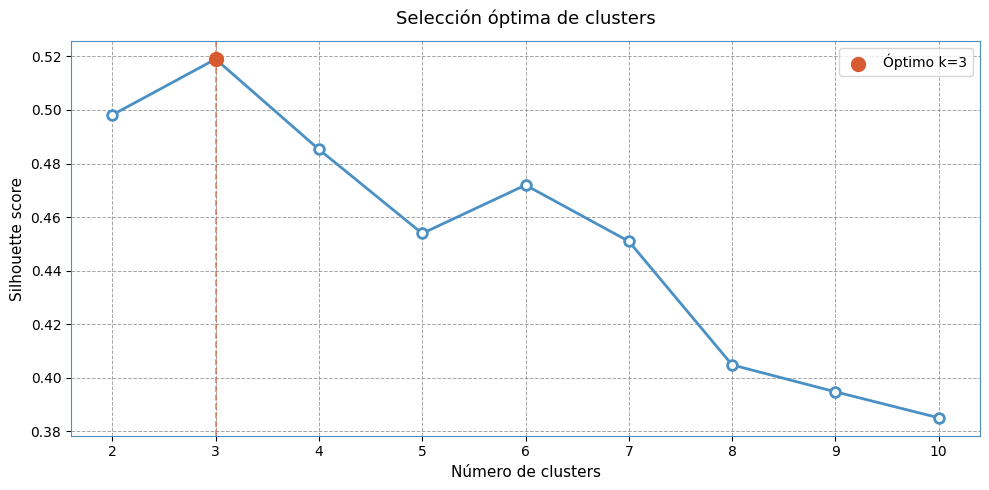

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(K, silhouette_scores, marker='o', color='#4a90c4', linewidth=2,
        markersize=7, markerfacecolor='white', markeredgecolor='#4a90c4', markeredgewidth=2)

# Marca el punto óptimo
best_k = K[silhouette_scores.index(max(silhouette_scores))]
best_score = max(silhouette_scores)

ax.scatter([best_k], [best_score], color='#d85a30', zorder=5, s=100, label=f'Óptimo k={best_k}')
ax.axvline(x=best_k, color='#d85a30', linestyle='--', linewidth=1.2, alpha=0.7)

ax.set_xlabel('Número de clusters', fontsize=11)
ax.set_ylabel('Silhouette score', fontsize=11)
ax.set_title('Selección óptima de clusters', fontsize=13, pad=12)
ax.set_xticks(K)
ax.grid(linestyle='--', linewidth=0.7, alpha=0.7, color='gray')
ax.set_axisbelow(True)
ax.legend(fontsize=10)

for spine in ax.spines.values():
    spine.set_edgecolor('#4a90c4')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.show()


## 6. Entrenamiento del modelo

Se entrena el modelo K-Means con el número óptimo de clusters encontrado en la etapa anterior. `random_state=42` garantiza que los resultados sean reproducibles en cada ejecución. Una vez entrenado, las etiquetas de cluster se añaden al DataFrame original como una nueva columna `Cluster`.

In [29]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [30]:
df['Cluster'] = kmeans.labels_

## 7. Evaluación del modelo

En esta etapa se calcula el **Silhouette Score final** del modelo entrenado, que mide la calidad de la separación entre los clusters obtenidos. Además, se analiza la distribución de muestras por cluster para detectar desbalances, y se calcula el promedio de cada variable por cluster para interpretar el perfil morfológico de cada grupo.

In [31]:
final_score = silhouette_score(
    X_scaled,
    kmeans.labels_
)

print(f'Silhouette Score Final: {final_score}')

Silhouette Score Final: 0.5190007679364604


`value_counts()` muestra cuántas muestras fueron asignadas a cada cluster. Permite identificar si los grupos están balanceados o si algún cluster concentra la mayoría de los datos.

In [32]:
df['Cluster'].value_counts()

Cluster
2    7951
0    5136
1     524
Name: count, dtype: int64

Se calcula el promedio de cada variable morfológica por cluster. Esto permite interpretar el perfil típico de cada grupo: por ejemplo, un cluster con `Area` y `Perimeter` altos corresponderá a frijoles de mayor tamaño, mientras que un cluster con `Compactness` alta indicará frijoles de forma más circular.

In [33]:
cluster_analysis = df.groupby('Cluster')[features].mean()

cluster_analysis

,Area,Perimeter,MajorAxisLength,MinorAxisLength,Compactness
Cluster,,,,,
0,64780.498442,994.254537,382.588608,215.888766,0.747755
1,173264.839695,1584.640353,592.700642,374.122583,0.792691
2,37547.073953,717.446901,261.841369,182.148378,0.833997


## 8. Visualización de resultados

Dado que el dataset tiene 5 dimensiones, se aplica **PCA** para reducirlo a 2 componentes y así poder visualizar los clusters en un plano bidimensional. PCA encuentra las direcciones de mayor varianza en los datos y proyecta los puntos sobre ellas, preservando la mayor cantidad de información posible.

El gráfico de dispersión resultante muestra cada frijol coloreado según el cluster asignado por el modelo, lo que permite evaluar visualmente la separación entre grupos.

In [34]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [35]:
pca_df = pd.DataFrame()

pca_df['PCA1'] = X_pca[:,0]
pca_df['PCA2'] = X_pca[:,1]

pca_df['Cluster'] = kmeans.labels_

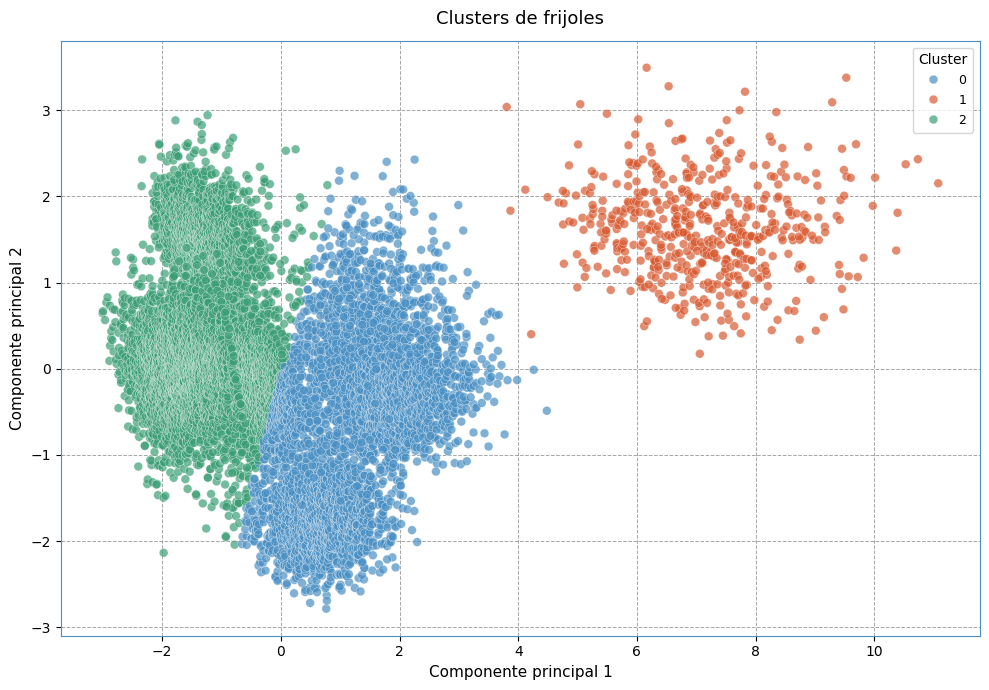

In [37]:
fig, ax = plt.subplots(figsize=(10, 7))

palette = ['#4a90c4', '#d85a30', '#3b9e75', '#e8a020', '#9b59b6', '#e74c3c', '#1abc9c']
n_clusters = pca_df['Cluster'].nunique()

sns.scatterplot(
    data=pca_df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette=palette[:n_clusters],
    alpha=0.7,
    s=40,
    edgecolor='white',
    linewidth=0.3,
    ax=ax
)

ax.set_title('Clusters de frijoles', fontsize=13, pad=12)
ax.set_xlabel('Componente principal 1', fontsize=11)
ax.set_ylabel('Componente principal 2', fontsize=11)
ax.grid(linestyle='--', linewidth=0.7, alpha=0.7, color='gray')
ax.set_axisbelow(True)

legend = ax.get_legend()
legend.set_title('Cluster', prop={'size': 10})
for text in legend.get_texts():
    text.set_fontsize(9)

for spine in ax.spines.values():
    spine.set_edgecolor('#4a90c4')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.show()

## 9. Serialización del modelo

Se guardan tanto el modelo entrenado como el scaler utilizando `joblib`, lo que permite reutilizarlos en producción sin necesidad de re-entrenar. Es importante guardar el scaler junto con el modelo, ya que cualquier dato nuevo debe ser estandarizado con los mismos parámetros aprendidos durante el entrenamiento  antes de ser procesado por el modelo.

In [50]:
joblib.dump(
    kmeans,
        "../models/kmeans_model.pkl"
)

['../models/kmeans_model.pkl']

In [51]:
joblib.dump(
    scaler,
    '../models/scaler.pkl'
)

['../models/scaler.pkl']

## 10. Interpretación de resultados

- El modelo K-Means logró identificar patrones de segmentación en los datos morfológicos de los frijoles, agrupándolos según sus características de forma y tamaño.
- El **Silhouette Score final** indica la calidad de la separación entre clusters: valores por encima de 0.5 se consideran aceptables, y valores por encima de 0.7 indican una separación sólida.
- El análisis de promedios por cluster permite asociar cada grupo a un perfil morfológico específico, lo que facilita la interpretación de los segmentos encontrados.
- La visualización con PCA confirma visualmente si los clusters están bien separados o si existe solapamiento entre grupos.

## 11. Conclusiones

El modelo K-Means aplicado al Dry Bean Dataset permitió realizar una segmentación de frijoles basada en características morfológicas. La estandarización previa de los datos fue clave para evitar sesgos en el cálculo de distancias. La búsqueda del `k` óptimo mediante Silhouette Score y la visualización con PCA constituyen un flujo de trabajo robusto y reproducible para tareas de clustering.